[Paths]
  NOTEBOOK  = E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Supplementary
  LEVELS    = E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Supplementary/levels
  PUBLISH   = E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Supplementary/publish
  STATIONS  = E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Fig4/data/station_wspd_wdir/results_obs_newT/mean_wspd_obs.csv
  GROUP_MD  = E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Fig6/data/20260323-材料说明.md


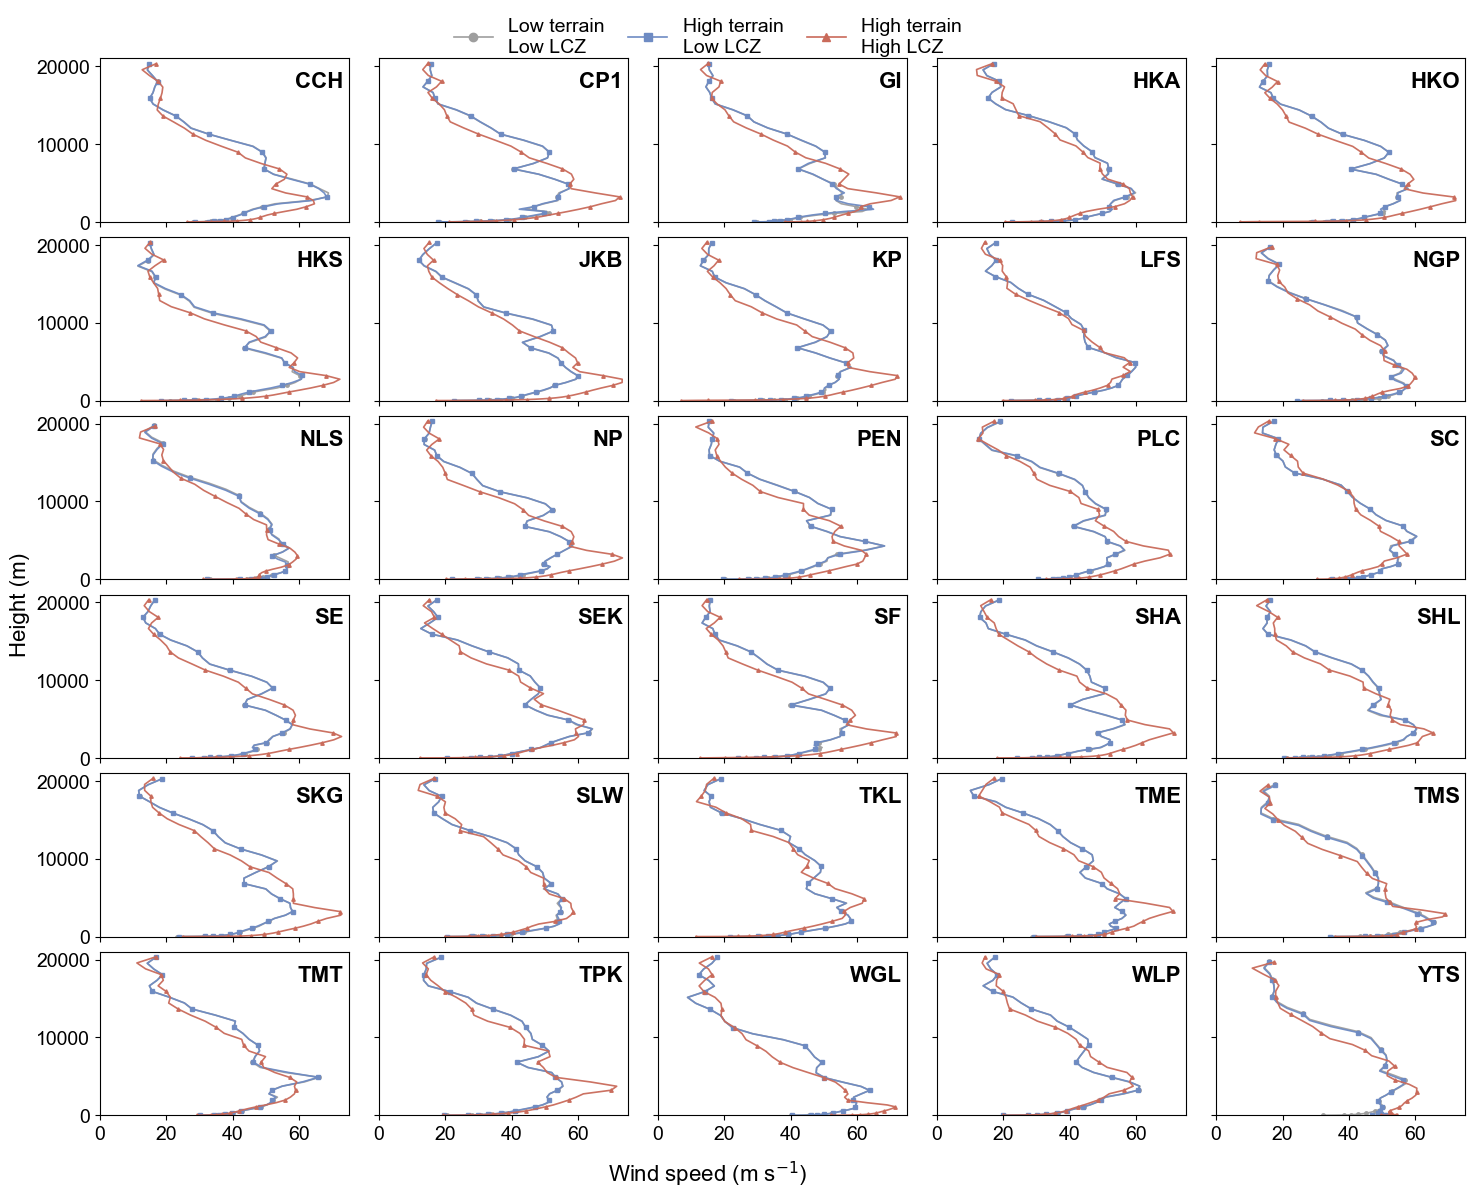

[Saved] 24h: publish\wind_profile_20250923_22_24h.tif
[Axis] x_max=75.0 m/s, y_range=(0.0, 21000.0) m


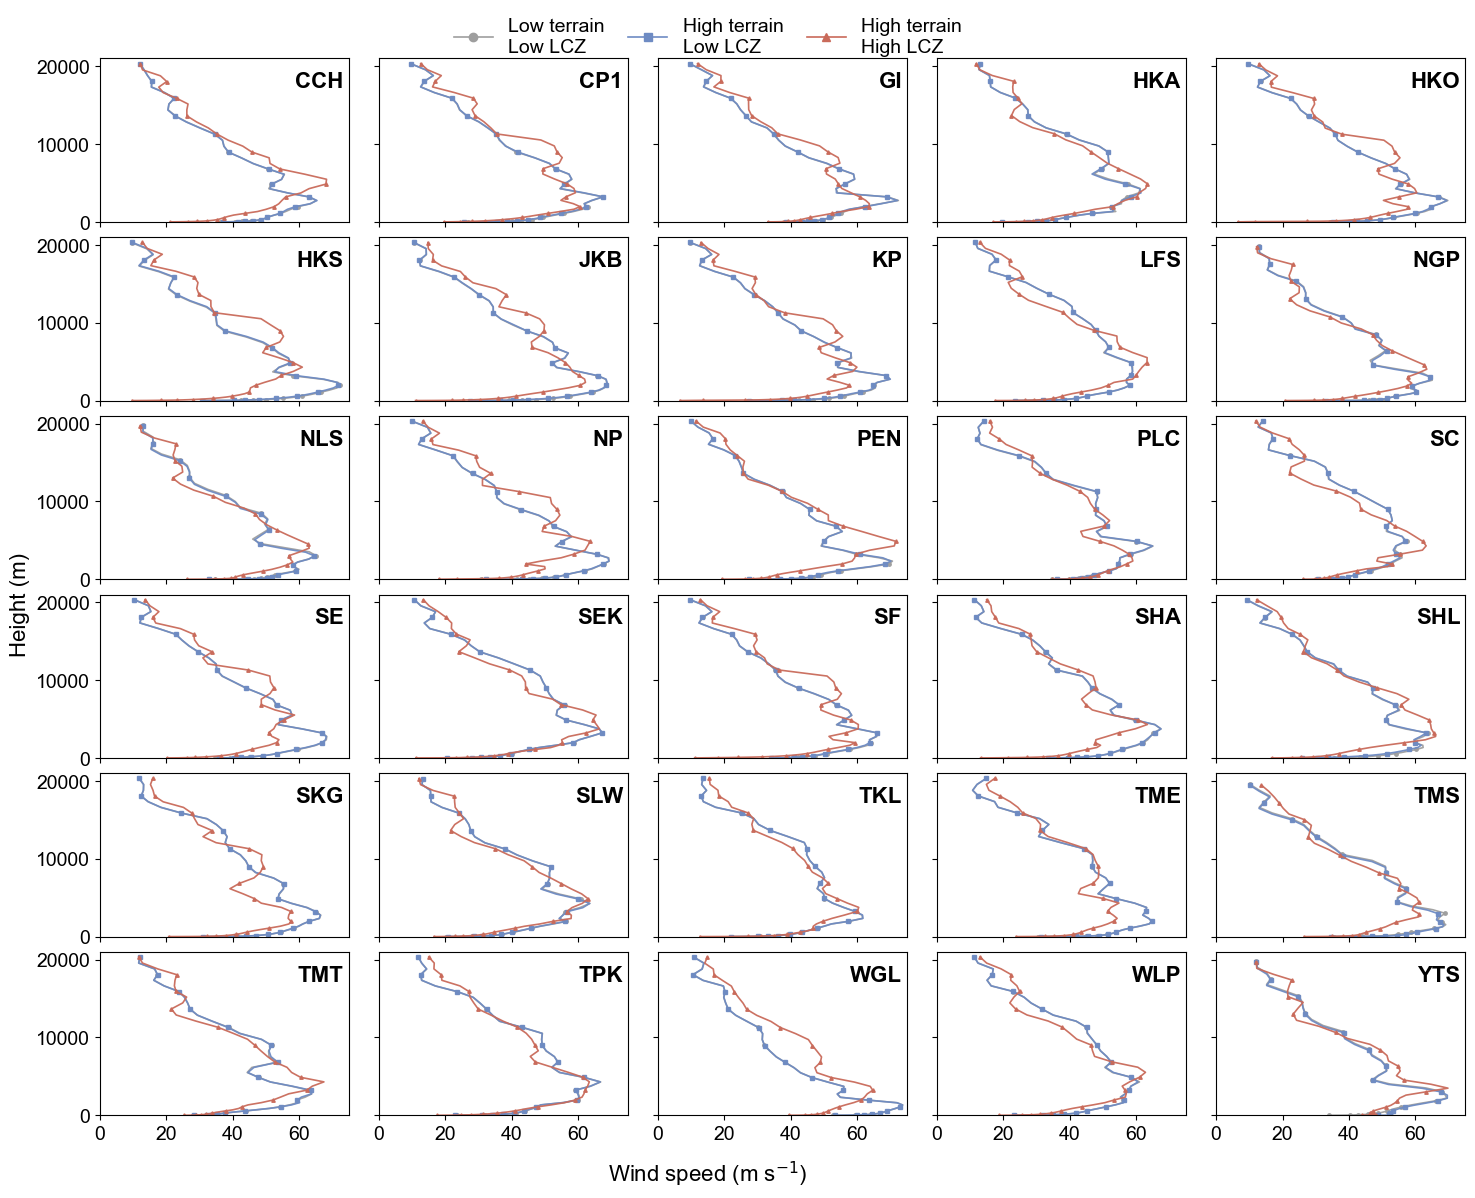

[Saved] 48h: publish\wind_profile_20250923_22_48h.tif
[Axis] x_max=75.0 m/s, y_range=(0.0, 21000.0) m

Saved files:
  24h -> publish\wind_profile_20250923_22_24h.tif
  48h -> publish\wind_profile_20250923_22_48h.tif


{'24h': WindowsPath('publish/wind_profile_20250923_22_24h.tif'),
 '48h': WindowsPath('publish/wind_profile_20250923_22_48h.tif')}

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----------------------------------------------------------------------------
# Settings
# ----------------------------------------------------------------------------
VALID_TAG = "2025-09-23_22"  # file tag in ./levels
VALID_TAG_OUT = "20250923_22"  # output tag (no separators)
LEADS = ["24h", "48h"]

# Surface-condition cases (ERA5-driven) — align with Fig6/03_rmse_terrain_lcz.ipynb
CASE_ORDER = [
    "era5_no_lcz_no_srtm",  # Low terrain / Low LCZ
    "era5_no_lcz",  # High terrain / Low LCZ
    "era5",  # High terrain / High LCZ
]

CASE_META: dict[str, dict[str, str]] = {
    "era5_no_lcz_no_srtm": {
        "label": "Low terrain\nLow LCZ",
        "color": "#9E9E9E",
        "marker": "o",
    },
    "era5_no_lcz": {
        "label": "High terrain\nLow LCZ",
        "color": "#6E8BC3",
        "marker": "s",
    },
    "era5": {
        "label": "High terrain\nHigh LCZ",
        "color": "#C96A5A",
        "marker": "^",
    },
}

# ----------------------------------------------------------------------------
# Paths (robust to CWD)
# NOTE: VS Code notebooks sometimes run with CWD = workspace root.
#       The fallback below makes paths work whether CWD is Supplementary/ or its parent.
# ----------------------------------------------------------------------------
FIG_DIR = Path("Supplementary") if Path("Supplementary").is_dir() else Path(".")
ROOT_DIR = FIG_DIR.resolve().parent

HERE = FIG_DIR.resolve()
LEVELS_DIR = FIG_DIR / "levels"
PUBLISH_DIR = FIG_DIR / "publish"
PUBLISH_DIR.mkdir(parents=True, exist_ok=True)

# Station order: follow Fig4 (30-station grid)
STATION_LIST_FILE = ROOT_DIR / "Fig4/data/station_wspd_wdir/results_obs_newT/mean_wspd_obs.csv"

# Station-group definitions (used for LLJ summary)
GROUP_MD = ROOT_DIR / "Fig6/data/20260323-材料说明.md"

# ----------------------------------------------------------------------------
# Plot style (match Fig4 baseline)
# ----------------------------------------------------------------------------
plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
    }
)

print("[Paths]")
print("  NOTEBOOK  =", HERE.as_posix())
print("  LEVELS    =", LEVELS_DIR.resolve().as_posix())
print("  PUBLISH   =", PUBLISH_DIR.resolve().as_posix())
print("  STATIONS  =", STATION_LIST_FILE.resolve().as_posix())
print("  GROUP_MD  =", GROUP_MD.resolve().as_posix())

if not LEVELS_DIR.exists():
    raise FileNotFoundError(f"Missing levels directory: {LEVELS_DIR}")

if not STATION_LIST_FILE.exists():
    raise FileNotFoundError(f"Missing station list file: {STATION_LIST_FILE}")

if not GROUP_MD.exists():
    raise FileNotFoundError(f"Missing station-group markdown: {GROUP_MD}")


def read_station_order(station_csv: Path) -> list[str]:
    header = pd.read_csv(station_csv, nrows=0).columns.tolist()
    if "timestamp_utc" not in header:
        raise ValueError(f"Expected a 'timestamp_utc' column in {station_csv}")
    stations = [c for c in header if c != "timestamp_utc"]
    return stations


def load_levels_var(case_key: str, lead: str, var: str, valid_tag: str) -> pd.DataFrame:
    filename = f"{case_key}_{lead}_{var}_{valid_tag}.csv"
    path = LEVELS_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing input file: {path}")

    df = pd.read_csv(path)
    if "eta_layer" not in df.columns:
        raise ValueError(f"Expected 'eta_layer' as the first column in {path}")

    df = df.set_index("eta_layer")
    # ensure numeric
    df = df.apply(pd.to_numeric, errors="coerce")
    return df


def load_profiles_for_lead(
    lead: str,
) -> tuple[list[str], dict[str, pd.DataFrame], dict[str, pd.DataFrame]]:
    """Return (stations, height_agl_by_case, wspd_by_case) for a given lead."""
    stations = read_station_order(STATION_LIST_FILE)

    if len(stations) != 30:
        raise ValueError(f"Expected 30 stations for Fig4-style 5×6 grid, got {len(stations)}")

    height_agl_by_case: dict[str, pd.DataFrame] = {}
    wspd_by_case: dict[str, pd.DataFrame] = {}

    for case_key in CASE_ORDER:
        ph = load_levels_var(case_key, lead, "PH", VALID_TAG)
        uu = load_levels_var(case_key, lead, "UU", VALID_TAG)
        vv = load_levels_var(case_key, lead, "VV", VALID_TAG)

        for var_name, df in {"PH": ph, "UU": uu, "VV": vv}.items():
            missing = [s for s in stations if s not in df.columns]
            if missing:
                raise ValueError(f"{case_key} {lead} {var_name} missing stations: {missing}")

        # Height above ground level (AGL) using near-surface PH as reference
        ph_sel = ph[stations]
        ph0 = ph_sel.iloc[0]
        height_agl = ph_sel.subtract(ph0, axis="columns")

        # Wind speed magnitude (m/s)
        wspd = np.hypot(uu[stations], vv[stations])

        height_agl_by_case[case_key] = height_agl
        wspd_by_case[case_key] = wspd

    return stations, height_agl_by_case, wspd_by_case


def build_legend_handles() -> list[Line2D]:
    handles: list[Line2D] = []
    for case_key in CASE_ORDER:
        meta = CASE_META[case_key]
        handles.append(
            Line2D(
                [],
                [],
                color=meta["color"],
                marker=meta["marker"],
                linestyle="-",
                linewidth=1.2,
                markersize=6,
                label=meta["label"],
            )
        )
    return handles


def nice_upper_limit(value: float, step: float) -> float:
    if not np.isfinite(value):
        return value
    return float(np.ceil(value / step) * step)


def plot_profiles_allstations(lead: str) -> Path:
    stations, height_agl_by_case, wspd_by_case = load_profiles_for_lead(lead)

    # Axis limits (shared across subplots for this lead)
    max_wspd = max(float(np.nanmax(df.to_numpy())) for df in wspd_by_case.values())
    max_hgt = max(float(np.nanmax(df.to_numpy())) for df in height_agl_by_case.values())

    x_max = nice_upper_limit(max_wspd, step=5.0)
    y_min = 0.0
    y_max = nice_upper_limit(max_hgt, step=1000.0 if max_hgt > 5000 else 500.0)

    ncols, nrows = (5, 6)
    if len(stations) != ncols * nrows:
        raise ValueError(f"Expected {ncols*nrows} stations for a {ncols}×{nrows} grid, got {len(stations)}")

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16.0, 12.8),
        sharex=True,
        sharey=True,
    )
    axes_flat = axes.ravel().tolist()

    for i, station in enumerate(stations):
        ax = axes_flat[i]

        for case_key in CASE_ORDER:
            meta = CASE_META[case_key]
            profile = (
                pd.DataFrame(
                    {
                        "wspd": wspd_by_case[case_key][station],
                        "height_agl": height_agl_by_case[case_key][station],
                    }
                )
                .dropna()
                .sort_values("height_agl")
            )
            if profile.empty:
                continue

            ax.plot(
                profile["wspd"],
                profile["height_agl"],
                color=meta["color"],
                marker=meta["marker"],
                linewidth=1.2,
                markersize=2.5,
                markevery=3,
                alpha=0.95,
            )

        ax.text(
            0.98,
            0.92,
            station.upper(),
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=16,
            weight="bold",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1.0),
        )

        ax.set_xlim(0, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(False)

    # Axis labeling: only left column and bottom row (match Fig4 pattern)
    for r in range(nrows):
        for c in range(ncols):
            ax = axes[r, c]
            ax.tick_params(axis="y", labelleft=(c == 0))
            ax.tick_params(axis="x", labelbottom=(r == nrows - 1))

    fig.text(0.5, 0.055, "Wind speed (m s$^{-1}$)", ha="center", va="center")
    fig.text(0.07, 0.5, "Height (m)", ha="center", va="center", rotation="vertical")

    handles = build_legend_handles()
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.972),
        ncol=len(handles),
        frameon=False,
        handlelength=2.0,
        columnspacing=1.2,
    )

    fig.tight_layout(rect=(0.065, 0.06, 0.995, 0.945), w_pad=0.30, h_pad=0.18)
    fig.subplots_adjust(wspace=0.12)

    out_path = PUBLISH_DIR / f"wind_profile_{VALID_TAG_OUT}_{lead}.tif"
    fig.savefig(out_path, dpi=600, bbox_inches="tight")
    plt.show()

    print(f"[Saved] {lead}: {out_path}")
    print(f"[Axis] x_max={x_max:.1f} m/s, y_range=({y_min:.1f}, {y_max:.1f}) m")
    return out_path


# ----------------------------------------------------------------------------
# Generate figures (24h then 48h)
# ----------------------------------------------------------------------------
outputs: dict[str, Path] = {}
for lead in LEADS:
    outputs[lead] = plot_profiles_allstations(lead)

print("\nSaved files:")
for lead, path in outputs.items():
    print(f"  {lead} -> {path}")

outputs

In [2]:
# ----------------------------------------------------------------------------
# Low-level jet (LLJ) diagnostics (grouped by surface category)
# ----------------------------------------------------------------------------
# Definition used here (adjustable):
# - "Low-level" = heights <= LLJ_MAX_HEIGHT_M (AGL)
# - Jet core = maximum wind speed within low-level
# - Jet layer range = contiguous vertical levels around the core where
#   wind speed >= LLJ_FRAC * (core wind speed)

import re

import numpy as np
import pandas as pd
from IPython.display import display

LLJ_MAX_HEIGHT_M = 3000.0
LLJ_FRAC = 0.80


def detect_llj_from_profile(
    height_m: np.ndarray,
    wspd_ms: np.ndarray,
    *,
    max_height_m: float,
    frac: float,
) -> dict[str, float] | None:
    mask = np.isfinite(height_m) & np.isfinite(wspd_ms)
    if not np.any(mask):
        return None

    height_m = np.asarray(height_m[mask], dtype=float)
    wspd_ms = np.asarray(wspd_ms[mask], dtype=float)

    order = np.argsort(height_m)
    height_m = height_m[order]
    wspd_ms = wspd_ms[order]

    ll_mask = height_m <= max_height_m
    if not np.any(ll_mask):
        return None

    h = height_m[ll_mask]
    w = wspd_ms[ll_mask]

    i_core = int(np.nanargmax(w))
    core_h = float(h[i_core])
    core_w = float(w[i_core])

    if not np.isfinite(core_w) or core_w <= 0:
        return None

    thresh = frac * core_w
    above = w >= thresh

    left = i_core
    while left > 0 and bool(above[left - 1]):
        left -= 1

    right = i_core
    while right < len(above) - 1 and bool(above[right + 1]):
        right += 1

    bottom_h = float(h[left])
    top_h = float(h[right])

    return {
        "jet_core_height_m": core_h,
        "jet_core_wspd_ms": core_w,
        "jet_bottom_m": bottom_h,
        "jet_top_m": top_h,
        "jet_thickness_m": top_h - bottom_h,
    }


def compute_llj_table_for_lead(
    lead: str, *, max_height_m: float, frac: float
) -> pd.DataFrame:
    stations, height_agl_by_case, wspd_by_case = load_profiles_for_lead(lead)

    rows: list[dict[str, object]] = []
    for station in stations:
        station_code = str(station).strip().upper()
        for case_key in CASE_ORDER:
            res = detect_llj_from_profile(
                height_agl_by_case[case_key][station].to_numpy(),
                wspd_by_case[case_key][station].to_numpy(),
                max_height_m=max_height_m,
                frac=frac,
            )
            if res is None:
                continue

            rows.append(
                {
                    "lead": lead,
                    "case_key": case_key,
                    "case_label": CASE_META[case_key]["label"].replace("\n", " / "),
                    "station": station_code,
                    **res,
                }
            )

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # Preserve desired case order (low→high surface detail)
    order_map = {k: i for i, k in enumerate(CASE_ORDER)}
    df["__corder"] = df["case_key"].map(order_map)
    df = df.sort_values(["lead", "__corder", "station"]).drop(columns=["__corder"])
    return df.reset_index(drop=True)


def _p(x: pd.Series, q: float) -> float:
    return float(np.nanpercentile(x.to_numpy(dtype=float), q))


def parse_station_groups(md_text: str) -> dict[str, list[str]]:
    lines = md_text.splitlines()

    start_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith("## 原图4-站点分类"):
            start_idx = i
            break
    if start_idx is None:
        raise ValueError("Cannot find section '## 原图4-站点分类' in markdown.")

    end_idx = len(lines)
    for i in range(start_idx + 1, len(lines)):
        if lines[i].strip().startswith("## "):
            end_idx = i
            break

    section_lines = lines[start_idx + 1 : end_idx]

    groups: list[tuple[int, str, list[str]]] = []
    for line in section_lines:
        line = line.strip()
        # e.g. "1. 城市中心：天文台hko，中环码头cp1..."
        m = re.match(r"^(\d+)\.\s*(.+?)[：:]\s*(.+)$", line)
        if not m:
            continue

        idx = int(m.group(1))
        group_name = m.group(2).strip()
        content = m.group(3).strip().rstrip("；;。.")

        items = re.split(r"[，,、]\s*", content)
        codes: list[str] = []
        for item in items:
            item = item.strip().rstrip("；;。.")
            if not item:
                continue
            m_code = re.search(r"([A-Za-z0-9]+)\s*$", item)
            if m_code:
                codes.append(m_code.group(1).upper())

        groups.append((idx, group_name, codes))

    groups = sorted(groups, key=lambda x: x[0])
    group_dict = {name: codes for _, name, codes in groups}

    if len(group_dict) != 5:
        raise ValueError(
            f"Expected 5 groups, got {len(group_dict)}. Parsed: {list(group_dict.keys())}"
)

    return group_dict


def group_label_en(group_name_cn: str) -> str:
    g = str(group_name_cn)
    if "城市中心" in g:
        return "Urban"
    if "内陆" in g:
        return "Plain"
    if "海边" in g:
        return "Coastal"
    if "海岛" in g:
        return "Island"
    if ("山地" in g) or ("森林" in g):
        return "Mountainous"
    return g


print("[LLJ diagnostics]")
print(f"  Low-level max height = {LLJ_MAX_HEIGHT_M:.0f} m (AGL)")
print(f"  Jet-layer threshold  = {LLJ_FRAC:.0%} of core wind speed")

# Load station-group definitions (5 groups)
md_text = GROUP_MD.read_text(encoding="utf-8", errors="ignore")
station_groups_cn = parse_station_groups(md_text)
group_order_cn = list(station_groups_cn.keys())
group_cn_to_en = {cn: group_label_en(cn) for cn in group_order_cn}
group_order_en = [group_cn_to_en[cn] for cn in group_order_cn]

code_to_group_cn = {code: group_cn for group_cn, codes in station_groups_cn.items() for code in codes}
code_to_group_en = {code: group_cn_to_en[gcn] for code, gcn in code_to_group_cn.items()}

stations_all = [str(s).strip().upper() for s in read_station_order(STATION_LIST_FILE)]
ungrouped = sorted(set(stations_all) - set(code_to_group_en.keys()))
if ungrouped:
    print(f"[Info] Unclassified stations in the 30-station list (ignored in group stats): {len(ungrouped)}")
    print(ungrouped)

# Compute LLJ table for both leads
llj_all = pd.concat(
    [compute_llj_table_for_lead(lead, max_height_m=LLJ_MAX_HEIGHT_M, frac=LLJ_FRAC) for lead in LEADS],
    ignore_index=True,
)

if llj_all.empty:
    print("No LLJ results computed (empty table).")
else:
    # Attach station groups (only 23 stations covered by the 5 groups)
    llj_all["group_cn"] = llj_all["station"].map(code_to_group_cn)
    llj_all["group_en"] = llj_all["station"].map(code_to_group_en)

    # Per-lead overall range (across all stations and cases)
    for lead in LEADS:
        df_lead = llj_all[llj_all["lead"] == lead]
        if df_lead.empty:
            continue

        core_min = df_lead["jet_core_height_m"].min()
        core_max = df_lead["jet_core_height_m"].max()
        bottom_min = df_lead["jet_bottom_m"].min()
        top_max = df_lead["jet_top_m"].max()

        print(f"\n[{lead}] Jet core height range (AGL): {core_min:.1f}–{core_max:.1f} m")
        print(f"[{lead}] Jet layer vertical extent (AGL): {bottom_min:.1f}–{top_max:.1f} m")

    # Summary by group × case × lead (core height)
    llj_group = llj_all.dropna(subset=["group_en"]).copy()
    if llj_group.empty:
        print("\nNo grouped LLJ results computed (all stations unclassified?).")
    else:
        grouped = llj_group.groupby(["lead", "group_en", "case_key", "case_label"], observed=True)
        llj_summary = grouped.agg(
            n=("station", "size"),
            core_h_min_m=("jet_core_height_m", "min"),
            core_h_p25_m=("jet_core_height_m", lambda s: _p(s, 25)),
            core_h_median_m=("jet_core_height_m", "median"),
            core_h_p75_m=("jet_core_height_m", lambda s: _p(s, 75)),
            core_h_max_m=("jet_core_height_m", "max"),
        ).reset_index()

        llj_summary["__gorder"] = llj_summary["group_en"].apply(
            lambda x: group_order_en.index(x) if x in group_order_en else 999
)
        llj_summary["__corder"] = llj_summary["case_key"].apply(
            lambda x: CASE_ORDER.index(x) if x in CASE_ORDER else 999
)
        llj_summary = (
            llj_summary.sort_values(["lead", "__gorder", "__corder"])
            .drop(columns=["__gorder", "__corder"])
            .reset_index(drop=True)
)

        print("\nLLJ jet-core height summary by station group (AGL):")
        display(llj_summary)

        # Deltas (median core height): terrain vs LCZ impacts, aligned with Fig6 definitions
        med = llj_summary.pivot_table(
            index=["lead", "group_en"],
            columns="case_key",
            values="core_h_median_m",
            aggfunc="first",
)
        for k in CASE_ORDER:
            if k not in med.columns:
                med[k] = np.nan

        llj_delta = pd.DataFrame(
            {
                "delta_terrain_m": med["era5_no_lcz"] - med["era5_no_lcz_no_srtm"],
                "delta_lcz_m": med["era5"] - med["era5_no_lcz"],
            }
).reset_index()

        llj_delta["__gorder"] = llj_delta["group_en"].apply(
            lambda x: group_order_en.index(x) if x in group_order_en else 999
)
        llj_delta = (
            llj_delta.sort_values(["lead", "__gorder"])
            .drop(columns=["__gorder"])
            .reset_index(drop=True)
)

        print("\nMedian Δ (jet-core height, AGL):")
        print("  Δterrain = median(High terrain / Low LCZ) - median(Low terrain / Low LCZ)")
        print("  ΔLCZ     = median(High terrain / High LCZ) - median(High terrain / Low LCZ)")
        display(llj_delta)

    # Full table (expected ~180 rows = 30 stations × 3 cases × 2 leads, minus any missing profiles)
    print(f"\nRows in full LLJ table: {len(llj_all)}")
    display(llj_all)

[LLJ diagnostics]
  Low-level max height = 3000 m (AGL)
  Jet-layer threshold  = 80% of core wind speed
[Info] Unclassified stations in the 30-station list (ignored in group stats): 7
['HKA', 'HKS', 'JKB', 'PLC', 'SE', 'SLW', 'TME']

[24h] Jet core height range (AGL): 31.3–2947.5 m
[24h] Jet layer vertical extent (AGL): 0.0–2997.7 m

[48h] Jet core height range (AGL): 1323.3–2770.9 m
[48h] Jet layer vertical extent (AGL): 10.4–2992.1 m

LLJ jet-core height summary by station group (AGL):


,lead,group_en,case_key,case_label,n,core_h_min_m,core_h_p25_m,core_h_median_m,core_h_p75_m,core_h_max_m
0,24h,Urban,era5_no_lcz_no_srtm,Low terrain / Low LCZ,5,2749.76910,2753.843100,2754.966300,2755.663100,2755.99290
1,24h,Urban,era5_no_lcz,High terrain / Low LCZ,5,2749.12000,2751.586400,2755.252800,2757.712300,2758.34686
2,24h,Urban,era5,High terrain / High LCZ,5,2739.09740,2739.672900,2742.072000,2745.450100,2746.08387
3,24h,Plain,era5_no_lcz_no_srtm,Low terrain / Low LCZ,4,1958.61440,1959.832175,2358.817700,2757.825100,2759.10850
4,24h,Plain,era5_no_lcz,High terrain / Low LCZ,4,1960.41630,1960.576425,2359.071050,2758.176235,2760.16804
5,24h,Plain,era5,High terrain / High LCZ,4,2753.66790,2755.192500,2757.641435,2760.556153,2763.47810
6,24h,Coastal,era5_no_lcz_no_srtm,Low terrain / Low LCZ,4,2750.82400,2752.595275,2755.239450,2758.238225,2761.07330
7,24h,Coastal,era5_no_lcz,High terrain / Low LCZ,4,2753.34570,2756.395725,2757.515750,2759.062162,2763.39135
8,24h,Coastal,era5,High terrain / High LCZ,4,2752.52990,2752.715600,2752.828105,2755.419332,2763.04120
9,24h,Island,era5_no_lcz_no_srtm,Low terrain / Low LCZ,6,1622.75630,2052.121330,2535.916250,2744.301292,2750.63240



Median Δ (jet-core height, AGL):
  Δterrain = median(High terrain / Low LCZ) - median(Low terrain / Low LCZ)
  ΔLCZ     = median(High terrain / High LCZ) - median(High terrain / Low LCZ)


,lead,group_en,delta_terrain_m,delta_lcz_m
0,24h,Urban,0.28650,-13.180800
1,24h,Plain,0.25335,398.570385
2,24h,Coastal,2.27630,-4.687645
3,24h,Island,205.13280,8.448595
4,24h,Mountainous,-361.18100,914.441000
5,48h,Urban,-0.87090,-783.200110
6,48h,Plain,2.10360,6.519450
7,48h,Coastal,-390.89658,608.146830
8,48h,Island,-1.43429,0.691340
9,48h,Mountainous,164.57700,-198.453000



Rows in full LLJ table: 180


,lead,case_key,case_label,station,jet_core_height_m,jet_core_wspd_ms,jet_bottom_m,jet_top_m,jet_thickness_m,group_cn,group_en
0,24h,era5_no_lcz_no_srtm,Low terrain / Low LCZ,CCH,2745.40960,63.065307,2322.80960,2745.40960,422.600,海岛,Island
1,24h,era5_no_lcz_no_srtm,Low terrain / Low LCZ,CP1,2755.99290,53.967062,563.88390,2755.99290,2192.109,城市中心,Urban
2,24h,era5_no_lcz_no_srtm,Low terrain / Low LCZ,GI,1622.75630,63.097338,1087.14630,2755.56630,1668.420,海岛,Island
3,24h,era5_no_lcz_no_srtm,Low terrain / Low LCZ,HKA,2752.17746,53.504360,446.81946,2752.17746,2305.358,NaN,NaN
4,24h,era5_no_lcz_no_srtm,Low terrain / Low LCZ,HKO,2754.96630,55.302290,565.06930,2754.96630,2189.897,城市中心,Urban
...,...,...,...,...,...,...,...,...,...,...,...
175,48h,era5,High terrain / High LCZ,TMT,2760.25536,56.921293,1624.33536,2760.25536,1135.920,海岛,Island
176,48h,era5,High terrain / High LCZ,TPK,2762.92550,61.756443,1335.70550,2762.92550,1427.220,低矮建筑加海边,Coastal
177,48h,era5,High terrain / High LCZ,WGL,2752.59560,63.016495,451.05460,2752.59560,2301.541,海岛,Island
178,48h,era5,High terrain / High LCZ,WLP,2759.95390,56.947373,1333.79390,2759.95390,1426.160,低矮建筑加内陆平原,Plain
